In [16]:
import numpy as np
import pandas as pd
import seaborn as sns                      # 통계 전용 시각화 - matplotlib 같이 사용 가능 

import matplotlib.pyplot as plt            # 그래프 출력 옵션 (Detail)
import matplotlib as mpl                   # 외적인(큰틀) 옵션 - 한글, 사이즈 등  

mpl.rc('font', family='Malgun Gothic')     # 폰트 경로 - C:\Windows\Fonts\Malgun Gothic
plt.rcParams['axes.unicode_minus']=False   # 마이너스 설정 

# SET1 - LOT 물량 데이터 전처리 (workload)
- LOT 물량 데이터 : 원단 투입 중량 / 길이, 염색기 투입 액량, LOT별 생산 물량 등의 관련 데이터
- 설비 데이터 :  목표온도, 지시온도, 진행온도, 포속1 ~ 포속4 등의 운영 관련 데이터
- 품질 측정 데이터 (CCM 측정 결과) : 검사차수, 색조, 채도, 명도 등의 CCM 측정 결과 데이터

## 데이터 탐색

In [20]:
workload=pd.read_excel('./Data_Set/LOT_물량.xlsx')

In [21]:
workload.shape         # 크기

(2150, 7)

In [24]:
workload.head(2)       # 데이터 확인  (프로덕트, 프로세스)

,EXT1_QTY(투입중량 (KG)),EXT2_QTY (액량 (LITER)),PRODT_ORDER_NO,JOB_CD,PROCESS_CD,단위중량,염색 가동 길이
0,245.6,4000,F2111300008,F12-1203,F12-1203,590,120.0
1,71.4,600,F2111300012,F12-1203,F12-1203,445,123.0


In [27]:
workload.info()      # 데이터 정보 

<class 'pandas.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EXT1_QTY(투입중량 (KG))    2150 non-null   float64
 1   EXT2_QTY (액량 (LITER))  2150 non-null   int64  
 2   PRODT_ORDER_NO         2150 non-null   str    
 3   JOB_CD                 2150 non-null   str    
 4   PROCESS_CD             2150 non-null   str    
 5   단위중량                   2150 non-null   int64  
 6   염색 가동 길이               2150 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 174.4 KB


- 통계 관점
    - 수치형 데이터 : 연속형, 이산형
    - 범주형 데이터 : 명목형, 순서형
- 프로그램 관점
    - 숫자 (연속형) : int, float
    - 문자 (범주형) : str(object), categorical
    - 순서형 (날짜형) : datetime

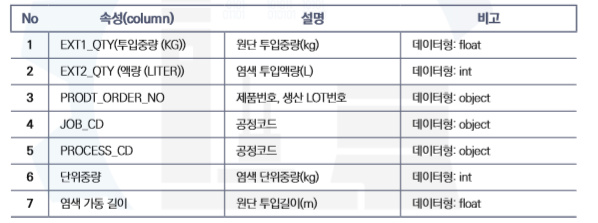

## 컬럼 추출 및 순서 변경
- 필요한 컬럼(변수) 추출 후 이름 수정

In [31]:
workload.columns

Index(['EXT1_QTY(투입중량 (KG))', 'EXT2_QTY (액량 (LITER))', 'PRODT_ORDER_NO',
       'JOB_CD', 'PROCESS_CD', '단위중량', '염색 가동 길이'],
      dtype='str')

In [33]:
# 공정코드중복 : 'JOB_CD', 'PROCESS_CD',
workload=workload[['PRODT_ORDER_NO', 'JOB_CD', 'EXT1_QTY(투입중량 (KG))', 
                   'EXT2_QTY (액량 (LITER))', '단위중량', '염색 가동 길이']]

In [35]:
workload.columns=['LOT번호', '공정코드', '투입중량(kg)', 
                  '투입액량(L)', '단위중량(kg)', '염색길이(m)']

In [37]:
workload.shape

(2150, 6)

In [39]:
workload.head(2)

,LOT번호,공정코드,투입중량(kg),투입액량(L),단위중량(kg),염색길이(m)
0,F2111300008,F12-1203,245.6,4000,590,120.0
1,F2111300012,F12-1203,71.4,600,445,123.0


- 중앙값과 평균이 비슷하면 정규분포인 경우 많다. (반드시는 아님)
- 변동계수(cv) : 표준편차가 얼마나 큰가? 비율
    - 표준편차 146.88 / 85.31 = 0.58
    - cv < 0.5 : 평균 주변 밀집 / cv > 1.0 광범위하게 퍼져 있다. 
- 이상치 (0과 1) 나중에 병합 후 처리
    - 25%과 min 차이
    - 50%와 max 차이

In [42]:
workload.describe().T.round(2)      # 데이터 분포 확인(IQR) 및 이상치

,count,mean,std,min,25%,50%,75%,max
투입중량(kg),2150.0,146.88,85.31,0.0,75.85,150.6,190.75,504.2
투입액량(L),2150.0,2460.37,1338.93,600.0,1000.00,2000.0,4000.00,4000.0
단위중량(kg),2150.0,390.44,194.84,0.0,234.00,400.0,560.00,1150.0
염색길이(m),2150.0,432.93,522.60,1.0,60.00,262.0,500.00,1600.0


In [44]:
workload.describe(include='str')

,LOT번호,공정코드
count,2150,2150
unique,2127,1
top,F2204120145,F12-1203
freq,4,2150


## 결측치

In [37]:
workload.isnull().sum()     

LOT번호       0
공정코드        0
투입중량(kg)    0
투입액량(L)     0
단위중량(kg)    0
염색길이(m)     0
dtype: int64

In [115]:
# total=workload.isnull().any(axis=1)       # 열 방향 단위로 확인 / 하나라도 있으면 true
# total.sum() / len(workload) * 100         # 30% 삭제 

## 데이터 형식 
- 범주형 : 대소문자 통일
- 연속형 : 데이터 타입 변경

In [42]:
workload.head(2)

,LOT번호,공정코드,투입중량(kg),투입액량(L),단위중량(kg),염색길이(m)
0,F2111300008,F12-1203,245.6,4000,590,120.0
1,F2111300012,F12-1203,71.4,600,445,123.0


In [46]:
# 소문자로 시작하는 데이터 계수 확인
workload['LOT번호'].str.islower().sum()

0

In [48]:
workload['공정코드'].str.islower().sum()

0

In [50]:
# 데이터 타입 변경
workload.info()

<class 'pandas.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LOT번호     2150 non-null   str    
 1   공정코드      2150 non-null   str    
 2   투입중량(kg)  2150 non-null   float64
 3   투입액량(L)   2150 non-null   int64  
 4   단위중량(kg)  2150 non-null   int64  
 5   염색길이(m)   2150 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 140.8 KB


In [52]:
workload=workload.astype({'투입액량(L)':'float', '단위중량(kg)':'float'})

In [54]:
workload.info()

<class 'pandas.DataFrame'>
RangeIndex: 2150 entries, 0 to 2149
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LOT번호     2150 non-null   str    
 1   공정코드      2150 non-null   str    
 2   투입중량(kg)  2150 non-null   float64
 3   투입액량(L)   2150 non-null   float64
 4   단위중량(kg)  2150 non-null   float64
 5   염색길이(m)   2150 non-null   float64
dtypes: float64(4), str(2)
memory usage: 140.8 KB


## 중복 데이터 
- 설비나 센서에서 데이터를 서버로 보낼 때 중복 발생
- 사용자(사람)의 실수
- 데이터 통합 과정에서 문제
- 중복 자체가 의미 있는 경우는 삭제 안함
    - Ex) 고객이 골라를 구매(각각 1구매를 두번 클릭), 제조 설비 알람 로그 (12:00:01 경고발생)

In [56]:
# 중복데이터 계수 확인
cond=workload.duplicated(keep=False)      # False:모든 중복데이터 포함, first:첫번째 중복데이터 제외
cond.sum()

38

In [58]:
# 중복데이터 내용 확인
workload[cond].head(6)

,LOT번호,공정코드,투입중량(kg),투입액량(L),단위중량(kg),염색길이(m)
8,F2111300043,F12-1203,193.6,4000.0,146.0,1600.0
9,F2111300043,F12-1203,193.6,4000.0,146.0,1600.0
251,F2112240047,F12-1203,102.6,1000.0,380.0,300.0
252,F2112240047,F12-1203,102.6,1000.0,380.0,300.0
467,F2201180073,F12-1203,102.1,4000.0,190.0,500.0
468,F2201180073,F12-1203,102.1,4000.0,190.0,500.0


In [60]:
workload2=workload.drop_duplicates(keep='first')       # 중복데이터 한개씩만 남기고 모두 삭제

In [64]:
workload2.reset_index(drop=True, inplace=True)         # 인덱스 리셋 

In [66]:
workload2.duplicated(keep=False).sum()                 # 중복 다시 확인

0

In [68]:
# LOT번호순으로 데이터 재 정렬
workload2.sort_values(by='LOT번호', inplace=True, ignore_index=True)   # 이그노어

## 비유일성 데이터 
- 테이블 결합 Key
    - 물량 데이터 : LOT번호
    - 공정 데이터 : LOT번호, 공정코드, 공정진행시간
    - 품질 측정 데이터 : LOT 번호, 검사차수
- LOT번호

In [70]:
# 데이터 유일성을 벗어나는 데이터 개수 확인
(workload2.groupby('LOT번호').size() > 1).sum()

2

In [72]:
# 비유일성 데이터 내용 확인
workload2[workload2.duplicated(subset='LOT번호', keep=False)]           # 염색길이 1 >> 수집 오류

,LOT번호,공정코드,투입중량(kg),투입액량(L),단위중량(kg),염색길이(m)
1646,F2207120068,F12-1203,279.0,3000.0,686.0,500.0
1647,F2207120068,F12-1203,279.0,3000.0,686.0,1.0
1938,F2209010042,F12-1203,191.8,4000.0,146.0,1600.0
1939,F2209010042,F12-1203,191.8,4000.0,146.0,1.0


In [74]:
# 비유일성 데이터 삭제
# workload3=workload2.drop([1647, 1939], axis=0)
workload3=workload2.drop_duplicates(subset='LOT번호', keep='first')

In [76]:
# 인덱스번호 리셋
workload3.reset_index(drop=True, inplace=True)

In [78]:
workload3.shape

(2127, 6)

In [80]:
# 비유일성 재확인
(workload3.groupby('LOT번호').size() > 1).sum()

0

## 파생변수

In [83]:
workload4=workload3.copy()

In [3]:
# 염색길이 1m당 투입된 중량(kg) 계산
# 작업 길이 차이를 제거하고 원단 단위 길이당 투입량을 비교하기 위한 지표
workload4['투입중량/길이']=workload4['투입중량(kg)'] / workload4['염색길이(m)']

In [87]:
# 액량 1L당 투입된 중량(kg) 계산
# 작업 규모 차이를 제거하고 배합 농도(중량 대비 액량 비율)를 비교하기 위한 지표
workload4['투입중량/액량']=workload4['투입중량(kg)'] / workload4['투입액량(L)']

In [89]:
workload4.head()

,LOT번호,공정코드,투입중량(kg),투입액량(L),단위중량(kg),염색길이(m),투입중량/길이,투입중량/액량
0,F2111300008,F12-1203,245.6,4000.0,590.0,120.0,2.046667,0.061400
1,F2111300012,F12-1203,71.4,600.0,445.0,123.0,0.580488,0.119000
2,F2111300020,F12-1203,98.3,4000.0,0.0,460.0,0.213696,0.024575
3,F2111300021,F12-1203,97.0,4000.0,0.0,452.0,0.214602,0.024250
4,F2111300027,F12-1203,40.6,600.0,445.0,86.0,0.472093,0.067667


# SET2 - 염색 공정 데이터 (operation)
- 시계열

## 데이터 탐색

In [124]:
# 경고 (low_memory) : 숫자랑 문자가 혼합되어 있으면, 판다스가 데이터 타입을 정하기 어렵다 
operation=pd.read_csv('./Data_Set/PRODUCTION_TREND.csv', encoding='cp949', low_memory=False)      

In [126]:
operation.shape            # 크기

(2119545, 15)

In [130]:
operation.head(2)          # 데이터 확인

,LOT_NO,WC_CD,WC_CNT,SEQ_NO,PGM_ID,RESOURCE_CD,CR_TEMP,TRD_TEMP_SP,TRD_TEMP_PV,TRD_SPEED1,TRD_SPEED2,TRD_SPEED3,TRD_SPEED4,INSRT_DT,PRODUCTION_RESULT_iD
0,F2112280005,F12-1203,1,1,B9700,FCM04,30,30.0,14.5,0,0,0,0,2022-01-03,NaN
1,F2112280005,F12-1203,1,2,B9700,FCM04,30,30.0,16.1,0,0,0,0,2022-01-03,NaN


In [104]:
operation.info()          # 데이터 정보

<class 'pandas.DataFrame'>
RangeIndex: 2119545 entries, 0 to 2119544
Data columns (total 15 columns):
 #   Column                Dtype  
---  ------                -----  
 0   LOT_NO                str    
 1   WC_CD                 str    
 2   WC_CNT                int64  
 3   SEQ_NO                int64  
 4   PGM_ID                str    
 5   RESOURCE_CD           str    
 6   CR_TEMP               int64  
 7   TRD_TEMP_SP           float64
 8   TRD_TEMP_PV           float64
 9   TRD_SPEED1            int64  
 10  TRD_SPEED2            int64  
 11  TRD_SPEED3            int64  
 12  TRD_SPEED4            int64  
 13  INSRT_DT              str    
 14  PRODUCTION_RESULT_iD  str    
dtypes: float64(2), int64(7), str(6)
memory usage: 324.7 MB


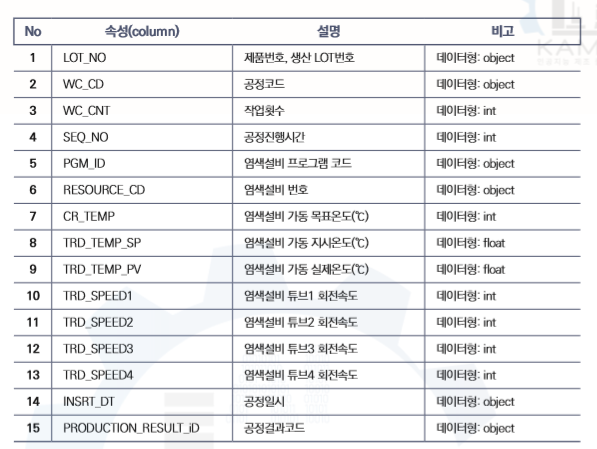

## 컬럼 추출 및 순서 변경

In [106]:
operation.columns

Index(['LOT_NO', 'WC_CD', 'WC_CNT', 'SEQ_NO', 'PGM_ID', 'RESOURCE_CD',
       'CR_TEMP', 'TRD_TEMP_SP', 'TRD_TEMP_PV', 'TRD_SPEED1', 'TRD_SPEED2',
       'TRD_SPEED3', 'TRD_SPEED4', 'INSRT_DT', 'PRODUCTION_RESULT_iD'],
      dtype='str')

In [108]:
operation=operation[['LOT_NO', 'WC_CD', 'RESOURCE_CD', 'INSRT_DT', 
                     'SEQ_NO', 'CR_TEMP', 'TRD_TEMP_SP','TRD_TEMP_PV', 
                     'TRD_SPEED1', 'TRD_SPEED2', 'TRD_SPEED3', 'TRD_SPEED4']]

In [110]:
operation.columns=['LOT번호', '공정코드', '설비번호', '공정일시', 
                   '공정진행시간', '목표온도', '지시온도', '진행온도', 
                   '포속1', '포속2', '포속3', '포속4']

In [112]:
operation.head(2)

,LOT번호,공정코드,설비번호,공정일시,공정진행시간,목표온도,지시온도,진행온도,포속1,포속2,포속3,포속4
0,F2112280005,F12-1203,FCM04,2022-01-03,1,30,30.0,14.5,0,0,0,0
1,F2112280005,F12-1203,FCM04,2022-01-03,2,30,30.0,16.1,0,0,0,0


In [114]:
operation.describe().T

,count,mean,std,min,25%,50%,75%,max
공정진행시간,2119545.0,164.241272,124.064699,1.0,73.0,147.0,227.0,1381.0
목표온도,2119545.0,5.694867,18.498098,0.0,0.0,0.0,0.0,138.0
지시온도,2119545.0,68.007681,36.079763,0.0,30.0,70.0,97.6,138.0
진행온도,2119545.0,69.482272,34.115828,0.0,37.2,69.5,97.3,152.5
포속1,2119545.0,101.302876,411.971363,0.0,23.0,65.0,99.0,9998.0
포속2,2119545.0,115.957423,207.606980,0.0,11.0,72.0,156.0,9027.0
포속3,2119545.0,91.250039,388.370409,0.0,0.0,61.0,99.0,9997.0
포속4,2119545.0,89.939476,247.838779,0.0,0.0,46.0,122.0,9058.0


In [116]:
operation.describe(include=str)

,LOT번호,공정코드,설비번호,공정일시
count,2119545,2119545,2119545,2119545
unique,7003,13,28,231
top,F2205260013,F12-1203,FCM04,2022-01-28
freq,1803,1155603,138758,16996


## 결측치

In [119]:
operation.isnull().sum()

LOT번호     0
공정코드      0
설비번호      0
공정일시      0
공정진행시간    0
목표온도      0
지시온도      0
진행온도      0
포속1       0
포속2       0
포속3       0
포속4       0
dtype: int64

## 데이터 형식

In [124]:
# 소문자로 시작하는 데이터 개수 확인
operation['LOT번호'].str.islower().sum()

0

In [126]:
operation['공정코드'].str.islower().sum()

0

## 중복 데이터 

In [131]:
cond=operation.duplicated(keep=False)     # False:모든 중복데이터 포함, first:첫번째 중복데이터 제외
cond.sum()

21600

In [135]:
operation[cond].head(2)

,LOT번호,공정코드,설비번호,공정일시,공정진행시간,목표온도,지시온도,진행온도,포속1,포속2,포속3,포속4
9165,F2112100004,F12-1203,FCM11,2022-01-03,1,30,30.0,28.2,0,0,0,0
9166,F2112100004,F12-1203,FCM11,2022-01-03,1,30,30.0,28.2,0,0,0,0


In [129]:
operation.sort_values(by=['LOT번호', '공정진행시간'], inplace=True, ignore_index=True)     # 인덱스 재정렬

In [137]:
operation2=operation.drop_duplicates(keep='first')

In [139]:
operation2.reset_index(drop=True, inplace=True)

In [141]:
operation2.duplicated().sum()

0

## 비유일성 데이터 
- LOT번호 + 공정코드 + 공정진행시간

In [144]:
# LOT번호, 공정진행시간 순으로 데이터 재정렬
# operation2.sort_values(by=['LOT번호', '공정진행시간'], inplace=True, ignore_index=True)

In [146]:
# 데이터 유일성을 벗어나는 데이터 개수 확인
(operation2.groupby(['LOT번호', '공정코드', '공정진행시간']).size() > 1).sum()

8841

In [148]:
# 비유일성 데이터 내용 확인
operation2[operation2.duplicated(subset=['LOT번호', '공정코드', '공정진행시간'], keep=False)].head(10)

,LOT번호,공정코드,설비번호,공정일시,공정진행시간,목표온도,지시온도,진행온도,포속1,포속2,포속3,포속4
43597,F2112270335추가,1,FCM06,2022-01-13,1,30,30.0,65.6,0,0,0,0
43598,F2112270335추가,1,FCM06,2022-01-13,1,30,30.0,66.8,0,0,0,0
43599,F2112270335추가,1,FCM06,2022-01-13,2,30,0.0,0.0,0,0,0,0
43600,F2112270335추가,1,FCM06,2022-01-13,2,30,50.0,64.4,0,0,0,0
43601,F2112270335추가,1,FCM06,2022-01-13,3,70,0.0,0.0,0,0,0,0
43602,F2112270335추가,1,FCM06,2022-01-13,3,30,50.0,62.9,0,0,0,0
43603,F2112270335추가,1,FCM06,2022-01-13,4,70,0.0,0.0,0,0,0,0
43604,F2112270335추가,1,FCM06,2022-01-13,4,30,50.0,35.6,0,1,0,0
43605,F2112270335추가,1,FCM06,2022-01-13,5,70,0.0,0.0,0,0,0,0
43606,F2112270335추가,1,FCM06,2022-01-13,5,30,50.2,40.4,15,2,15,1


In [150]:
# 중복데이터 한개씩 남기고 모두 삭제
operation3=operation2.drop_duplicates(subset=['LOT번호', '공정코드', '공정진행시간'], keep='last')

In [152]:
# 인덱스번호 리셋
operation3.reset_index(drop=True, inplace=True)

In [154]:
# 데이터 유일성 재확인
(operation3.groupby(['LOT번호', '공정코드', '공정진행시간']).size() > 1).sum()

0

## 파생변수
- SET1, SET3 : 비시계열
- SET2 : 시계열
- 이종간 결합
    - 물량 데이터 : LOT번호
    - 공정 데이터 : LOT번호, 공정코드, 공정진행시간
    - 품질 측정 데이터 : LOT번호, 검사차수
        - 결합 1: 물량 + 품질측징 >> LOT번호 결합
        - 결합 2 : 공정 + 결합 1  >> LOT번호, 공정코드 결합

In [157]:
# LOT별로 처리할 함수 정의
def calculate_progress(group):
    # 그룹 내에서 정렬
    group=group.sort_values(by='공정진행시간', ignore_index=True)
    # 진행률 계산
    group['공정진행시간(%)']=round(group['공정진행시간'] / group['공정진행시간'].max() * 100, 2)
    return group

In [159]:
operation4=operation3.groupby('LOT번호').apply(calculate_progress)
# operation4

In [160]:
operation4.reset_index(inplace=True)
# operation4.head()      # LOT번호(다중) >> level 자동 부여  

In [163]:
operation4.drop(columns='level_1', inplace=True)

In [165]:
operation4.head(2)

,LOT번호,공정코드,설비번호,공정일시,공정진행시간,목표온도,지시온도,진행온도,포속1,포속2,포속3,포속4,공정진행시간(%)
0,F2004270020,F12-1203,FCM12,2022-05-18,1,30,30.0,31.9,0,0,0,0,0.22
1,F2004270020,F12-1203,FCM12,2022-05-18,2,30,30.0,30.7,45,1,0,0,0.44


In [167]:
operation4.columns

Index(['LOT번호', '공정코드', '설비번호', '공정일시', '공정진행시간', '목표온도', '지시온도', '진행온도',
       '포속1', '포속2', '포속3', '포속4', '공정진행시간(%)'],
      dtype='str')

In [169]:
operation4=operation4[['LOT번호', '공정코드', '설비번호', '공정진행시간(%)', 
                       '목표온도', '지시온도', '진행온도','포속1', '포속2', '포속3', '포속4']]

In [171]:
operation4.shape

(2099361, 11)

# SET3 - 품질 측정 데이터 (CCM 검사결과)
## 데이터 탐색

In [175]:
ccm=pd.read_excel('./Data_Set/CCM_측정값.xlsx')            # CCM 검사결과데이터 확인 

In [177]:
ccm.shape              # 크기

(614, 9)

In [179]:
ccm.head(2)            # 데이터 확인

,lot_no,seq,oper_id,염색 색차 DL,염색 색차 DA,염색 색차 DB,염색 색차 DC,염색 색차 DH,염색 색차 DE
0,F2002240067,0,염색,1.402431,-0.079870,0.255513,0.063653,-0.260028,1.427754
1,F2003120058,0,염색,-0.043186,-0.021964,0.614762,0.032673,-0.614286,0.616669


In [181]:
ccm.info()            # 데이터 정보

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   lot_no    614 non-null    str    
 1   seq       614 non-null    object 
 2   oper_id   614 non-null    str    
 3   염색 색차 DL  614 non-null    float64
 4   염색 색차 DA  614 non-null    float64
 5   염색 색차 DB  614 non-null    float64
 6   염색 색차 DC  614 non-null    float64
 7   염색 색차 DH  614 non-null    float64
 8   염색 색차 DE  614 non-null    float64
dtypes: float64(6), object(1), str(2)
memory usage: 55.6+ KB


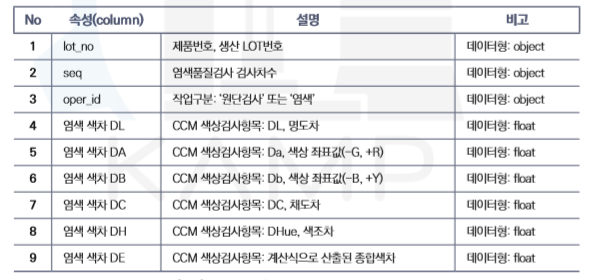

## 컬럼 추출 및 순서 변경

In [183]:
ccm.columns

Index(['lot_no', 'seq', 'oper_id', '염색 색차 DL', '염색 색차 DA', '염색 색차 DB',
       '염색 색차 DC', '염색 색차 DH', '염색 색차 DE'],
      dtype='str')

In [185]:
ccm=ccm[['lot_no', 'seq', 'oper_id', '염색 색차 DE']]

In [187]:
ccm.columns=['LOT번호', '검사차수', '작업명', '염색색차 DE']

In [189]:
ccm.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   LOT번호    614 non-null    str    
 1   검사차수     614 non-null    object 
 2   작업명      614 non-null    str    
 3   염색색차 DE  614 non-null    float64
dtypes: float64(1), object(1), str(2)
memory usage: 31.6+ KB


In [191]:
ccm.describe().T

,count,mean,std,min,25%,50%,75%,max
염색색차 DE,614.0,4.894348,10.348399,0.015057,0.734266,1.3941,2.926982,93.47859


In [193]:
ccm.describe(include=['str', 'object'])

,LOT번호,검사차수,작업명
count,614,614,614
unique,434,4,2
top,F2111110047,0,원단검사
freq,13,428,356


## 결측치

In [196]:
ccm.isnull().sum()

LOT번호      0
검사차수       0
작업명        0
염색색차 DE    0
dtype: int64

In [185]:
# total=ccm.isnull().any(axis=1)       # 열 방향, 즉 행 단위로 확인 / 하나라도 있으면 true
# total.sum() / len(ccm) * 100         # 30% 삭제 

## 데이터 형식

In [200]:
# 소문자로 시작하는 데이터 계수 확인
ccm['LOT번호'].str.islower().sum()

37

In [202]:
ccm[ccm['LOT번호'].str.islower()].head(2)

,LOT번호,검사차수,작업명,염색색차 DE
125,f2109240189,0,원단검사,0.654607
127,f2109240190,0,원단검사,0.277524


In [204]:
ccm['LOT번호']=ccm['LOT번호'].str.capitalize()   # 캐피털라이즈

In [206]:
ccm['LOT번호'].str.islower().sum()

0

## 중복 데이터

In [208]:
cond=ccm.duplicated(keep=False)
cond.sum()

44

In [210]:
ccm[cond].head()

,LOT번호,검사차수,작업명,염색색차 DE
170,F2111010033,0,염색,34.27313
171,F2111010033,0,염색,34.27313
172,F2111010033,1,염색,34.30603
173,F2111010033,1,염색,34.30603
174,F2111010033,1,염색,34.10254


In [212]:
ccm2=ccm.drop_duplicates(keep='first')

In [214]:
ccm2.reset_index(drop=True, inplace=True)

In [216]:
ccm2.duplicated().sum()

0

## 비유일성 데이터
- LOT번호 +  검사차수

In [219]:
# LOT번호, 검사차수 순으로 데이터 재정렬
ccm2.sort_values(by=['LOT번호', '검사차수'], inplace=True, ignore_index=True)

In [221]:
# 데이터 유일성을 벗어나느 데이터 개수 확인
(ccm2.groupby(['LOT번호', '검사차수']).size() > 1).sum()

52

In [223]:
# 비유일성 데이터 내용 확인
ccm2[ccm2.duplicated(subset=['LOT번호', '검사차수'], keep=False)].head()

,LOT번호,검사차수,작업명,염색색차 DE
3,F2009030093,0,원단검사,3.877990
4,F2009030093,0,원단검사,3.957100
21,F2104220009,0,원단검사,3.603126
22,F2104220009,0,원단검사,3.591169
30,F2105070082,1,염색,1.024476


In [194]:
# 설비데이터(SET2, operation 결합시, 검사차수 없음) 따라서 CCM의 검사차수는 기준값으로 사용 안함
# 설비데이터(독립변수): 그냥 LOT-A가 장비를 통과할 때의 전체 데이터만 있습니다. 
# (몇 번째 검사할 때 발생한 데이터인지 구분이 안 됨)

# CCM데이터(종속변수): LOT-A를 1번째 검사했을 때, 2번째 검사했을 때, 
# 3번째 검사했을 때처럼 '검사차수'별로 데이터가 여러 개 있습니다.

# 설비데이터를 쪼갤 수 있는 방법이 아예 없으니, 
# CCM데이터의 눈높이를 설비데이터(LOT번호 기준)에 맞추기로 타협한 것입니다.
# 즉, 여러 번 검사한 CCM데이터 중에서 '가장 마지막 검사 결과' 딱 1개만 원본으로 인정하고 나머지는 버리겠다는 뜻입니다.

# 왜 하필 마지막(last) 데이터인가요?
# 제조 공정에서는 재작업(Rework)이나 반복 검사를 할 때, 결국 최종 불량 여부를 판단하는 것은 
# '가장 마지막에 검사한 결과'이기 때문입니다. 앞의 1차, 2차 검사 결과는 과감히 포기하는 것이죠.

In [191]:
# LOT번호 기준으로 가장 마지막 값(=마지막 검사차수 값)만 추출

# ccm3=ccm2.groupby(['LOT번호']).last()
# ccm3.reset_index(drop=False, inplace=True)

In [225]:
ccm3=ccm2.drop_duplicates(subset='LOT번호', keep='last')

In [227]:
# 그룹함수를 통해 인덱스가 된 LOT번호를 다시 컬럼명으로 변경
ccm3.reset_index(drop=True, inplace=True)

In [229]:
ccm.shape, ccm3.shape

((614, 4), (427, 4))

In [231]:
ccm3.duplicated(subset=['LOT번호', '검사차수']).sum()

0

# 병합

- merge() : 두 개의 데이터프레임을 특정 열(인덱스 또는 열)을 기준으로 결합
    - 형식 : pd.merge(left=df1, right=df2, left_on='column name', right_on='column name', how='join 방법')
    - left=df1, right=df2 : 병합할 두개의 데이터 프레임 지정
    - left_on='column name', right_on='column name': 병합 기준이 되는 열을 지정
    - how=’join 방법’ : 병합 방법 지정
        - inner join : 조인 조건에 일치하는 정보를 조회
        - left join : 왼쪽 정보를 기준으로 결합한다. (왼쪽 정보가 조건에 부합하지 않아도 모두 결합)
        - right join : 오른쪽 정보를 기준으로 결합한다. (오른쪽 정보가 조건에 부합하지 않아도 모두 결합)
        - outer join : 조인 조건에 일치하지 않는 정보까지 모두 조회

In [229]:
apple=pd.DataFrame([[101, 'A'], 
                  [201, 'B'],
                  [301, 'C']],
                  columns=['id', 'value_apple'])
apple

,id,value_apple
0,101,A
1,201,B
2,301,C


In [237]:
banana=pd.DataFrame([[201, 'X'], 
                     [301, 'Y'], 
                     [401, 'Z']], 
                    columns=['id', 'value_banana'])
banana

,id,value_banana
0,201,X
1,301,Y
2,401,Z


In [242]:
# inner join : 조인 조건에 일치하는 정보를 조회
result_inner=pd.merge(left=apple, right=banana, left_on='id', right_on='id', how='inner')
result_inner  

,id,value_apple,value_banana
0,201,B,X
1,301,C,Y


In [246]:
# left join : 왼쪽 정보를 기준으로 결합한다. (왼쪽 정보가 조건에 부합하지 않아도 모두 결합)
result_left=pd.merge(left=apple, right=banana, left_on='id', right_on='id', how='left')
result_left

,id,value_apple,value_banana
0,101,A,NaN
1,201,B,X
2,301,C,Y


In [249]:
# right join : 오른쪽 정보를 기준으로 결합한다. (오른쪽 정보가 조건에 부합하지 않아도 모두 결합)
result_right=pd.merge(left=apple, right=banana, left_on='id', right_on='id', how='right')
result_right

,id,value_apple,value_banana
0,201,B,X
1,301,C,Y
2,401,NaN,Z


In [252]:
# outer join : 조인 조건에 일치하지 않는 정보까지 모두 조회
result_outer=pd.merge(left=apple, right=banana, left_on='id', right_on='id', how='outer')
result_outer

,id,value_apple,value_banana
0,101,A,NaN
1,201,B,X
2,301,C,Y
3,401,NaN,Z


In [254]:
result_outer=apple.merge(banana, on='id', how='outer')
result_outer

,id,value_apple,value_banana
0,101,A,NaN
1,201,B,X
2,301,C,Y
3,401,NaN,Z


In [234]:
# LOT 물량데이터 + CCM 데이터 결합 : LOT 번호 기준으로 결합
df=ccm3.merge(workload4,  on='LOT번호', how='inner')  
# df.head(2)

In [236]:
# 설비데이터(시계열) +	LOT 물량데이터 + CCM 데이터 결합 : LOT번호,	공정코드 기준으로 결합
df2=df.merge(operation4, on=['LOT번호', '공정코드'], how='inner')

In [238]:
df2.head(2)

,LOT번호,검사차수,작업명,염색색차 DE,공정코드,투입중량(kg),투입액량(L),단위중량(kg),염색길이(m),투입중량/길이,투입중량/액량,설비번호,공정진행시간(%),목표온도,지시온도,진행온도,포속1,포속2,포속3,포속4
0,F2201280039,0,원단검사,0.753096,F12-1203,44.6,1000.0,324.0,41.0,1.087805,0.0446,FCM08,0.19,30,30.0,10.9,0,0,0,0
1,F2201280039,0,원단검사,0.753096,F12-1203,44.6,1000.0,324.0,41.0,1.087805,0.0446,FCM08,0.39,30,30.0,10.3,16,1,16,1


In [240]:
workload4.shape, operation4.shape, ccm3.shape

((2127, 8), (2099361, 11), (427, 4))

In [242]:
df.shape, df2.shape

((127, 11), (34410, 20))

In [244]:
df2.columns

Index(['LOT번호', '검사차수', '작업명', '염색색차 DE', '공정코드', '투입중량(kg)', '투입액량(L)',
       '단위중량(kg)', '염색길이(m)', '투입중량/길이', '투입중량/액량', '설비번호', '공정진행시간(%)',
       '목표온도', '지시온도', '진행온도', '포속1', '포속2', '포속3', '포속4'],
      dtype='str')

In [246]:
df2=df2[['LOT번호', '검사차수', '작업명', '공정코드', '설비번호',
         '단위중량(kg)', '투입중량(kg)', '투입액량(L)','염색길이(m)', 
         '투입중량/길이', '투입중량/액량',  '공정진행시간(%)',
         '목표온도', '지시온도', '진행온도', '포속1', '포속2', '포속3', '포속4', '염색색차 DE']]

## 이상치 제거

In [249]:
df2.describe()

,단위중량(kg),투입중량(kg),투입액량(L),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),목표온도,지시온도,진행온도,포속1,포속2,포속3,포속4,염색색차 DE
count,34410.000000,34410.000000,34410.000000,34410.000000,34410.000000,34410.000000,34410.000000,34410.000000,34410.000000,34410.000000,34410.000000,34410.00000,34410.000000,34410.000000,34410.000000
mean,448.063383,136.295086,2027.538506,234.081255,10.643335,0.067530,49.761110,7.159547,85.044897,84.815065,67.863702,157.83406,117.330108,102.649056,2.043076
std,163.029422,86.847169,1196.773449,373.009418,32.734842,0.018442,28.803812,22.507373,31.310743,31.227978,64.578728,165.68275,280.007481,132.125127,2.946022
min,0.000000,19.800000,600.000000,1.000000,0.117125,0.021400,0.170000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.088128
25%,324.000000,60.800000,1000.000000,16.000000,0.511000,0.053300,24.802500,0.000000,70.000000,67.200000,39.000000,49.00000,46.000000,20.000000,0.607977
50%,460.000000,115.100000,2000.000000,83.000000,1.116667,0.066200,49.610000,0.000000,83.300000,83.400000,64.000000,109.00000,82.000000,68.000000,1.304339
75%,560.000000,189.100000,2000.000000,300.000000,4.715152,0.079300,74.580000,0.000000,112.800000,112.400000,87.000000,212.00000,109.000000,129.000000,2.015610
max,1150.000000,368.000000,4000.000000,1600.000000,201.400000,0.110150,100.000000,135.000000,135.000000,137.400000,2179.000000,1311.00000,6415.000000,1057.000000,17.202030


In [251]:
# 단위중량 이상치 개수 확인
len(df2[df2['단위중량(kg)'] == 0])

254

In [253]:
# 해당 이상치에 속한 LOT번호 확인
df2[df2['단위중량(kg)'] == 0]['LOT번호'].unique()

<ArrowStringArray>
['F2203230052']
Length: 1, dtype: str

In [255]:
# 단위 중량 이상치 제거
target_idx=df2[df2['단위중량(kg)'] == 0].index
# target_idx

In [ ]:
df2.drop(target_idx, inplace=True)

In [257]:
df2.reset_index(drop=True, inplace=True)

In [259]:
df2.shape

(34156, 20)

In [267]:
# 염색길이 이상치 제거
len(df2[df2['염색길이(m)'] == 1])

1548

In [269]:
# 해당 이상치에 속한 LOT번호 확인
df2[df2['염색길이(m)'] == 1]['LOT번호'].unique()

<ArrowStringArray>
['F2202180111', 'F2203100080', 'F2205300077', 'F2208040015', 'F2208040155']
Length: 5, dtype: str

In [271]:
# 염색길이 이상치 제거
target_idx=df2[df2['염색길이(m)'] == 1].index
# target_index

In [ ]:
df2.drop(target_idx, inplace=True)

In [273]:
df2.reset_index(drop=True, inplace=True)

In [275]:
df2.shape

(32608, 20)

## 결측치

In [207]:
# 결측치 비율
total=df2.isnull().any(axis=1)            # 열 방향 단위로 확인 / 하나라도 있으면 true
total.sum() / len(df2) * 100              # 30% 삭제 

0.0

In [ ]:
# 결측치 삭제 
# df2.dropna(inplace=True)

# 결측치 대체
# df.fillna(method='ffill')   # 앞에
# df.fillna(method='bfill')   # 뒤에

In [210]:
# 평균, 중앙값, 
def sub(series):
    # 기초 통계 계산
    q1=series.quantile(0.25)          # 콴타일    
    q3=series.quantile(0.75)             
    iqr=q3 - q1                           
    # print(q1, q3, iqr)

    # 하한값, 상한값 계산
    lower_bound=q1 - (1.5 * iqr)           
    upper_bound=q3 + (1.5 * iqr)            
    # print(lower_bound, upper_bound)
    # print(series.min(), series.max())    

    # 이상치 여부
    is_outlier=False
    if series.min() < lower_bound:    # 기준선 보다 작으면 이상치   0.0 < -124.65
        print(f"하위 이상치 존재! (최솟값 {series.min() } < 하한값 {lower_bound:.2f})")
        is_outlier=True

    elif series.max() > upper_bound:   # 기준선 보다 크면 이상치    350.8> 0.8499
        print(f"상위 이상치 존재! (최댓값 {series.max() } > 상한값 {upper_bound:.2f})")
        is_outlier=True

    # 최종 결정
    if is_outlier:
        print("중앙값 사용 권장")
    else:
        print("평균값 사용 권장")

In [214]:
sub(df2['염색길이(m)'])
# df2['염색길이(m)']=df2['염색길이(m)'].fillna(df2['염색길이(m)'].median())

상위 이상치 존재! (최댓값 1600.0 > 상한값 716.50)
중앙값 사용 권장


In [217]:
sub(df2['투입중량(kg)'])

평균값 사용 권장


## 불필요한 열 삭제

In [277]:
df3=df2.drop(['투입액량(L)', '목표온도'], axis=1)

In [279]:
df3.head(2)

,LOT번호,검사차수,작업명,공정코드,설비번호,단위중량(kg),투입중량(kg),염색길이(m),투입중량/길이,투입중량/액량,공정진행시간(%),지시온도,진행온도,포속1,포속2,포속3,포속4,염색색차 DE
0,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.19,30.0,10.9,0,0,0,0,0.753096
1,F2201280039,0,원단검사,F12-1203,FCM08,324.0,44.6,41.0,1.087805,0.0446,0.39,30.0,10.3,16,1,16,1,0.753096


In [287]:
df3.to_csv('./Data_Result/최종결합염색공정.csv', encoding='cp949', index=False)  

In [291]:
# 두 CSV 파일 읽기
a=pd.read_csv('./Data_Set/염색공정전체데이터.csv', encoding='cp949')
b=pd.read_csv('./Data_Result/최종결합염색공정.csv', encoding='cp949')

# 내용이 완전히 일치하는지 확인
if a.equals(b):
    print("두 CSV 파일의 내용이 완전히 동일합니다.")
else:
    print("두 CSV 파일의 내용이 다릅니다!")
    print(a.compare(b))    # 만약 Empty DataFrame 나오는 경우는 자료형 확인 

두 CSV 파일의 내용이 완전히 동일합니다.


## 시각화
- 단일 변수 : 한 가지 항목에 대한 시각화
    - 범주형 (문자) : countplot, pie
    - 연속형 (숫자) : histplot, boxplot
- 다중 변수
    - X(문자) / Y(숫자) : barplot
    - X(숫자) / Y(숫자) : scatter, heatmap
    - X(날짜) / Y(숫자) : lineplot
- 숫자 전체 : histplot, scatter

In [274]:
dye=pd.read_csv('./Data_Result/최종결합염색공정.csv', encoding='cp949')
dye.shape

(32608, 18)

In [2]:
# dye.columns

### 단일변수 - 범주형(문자) 

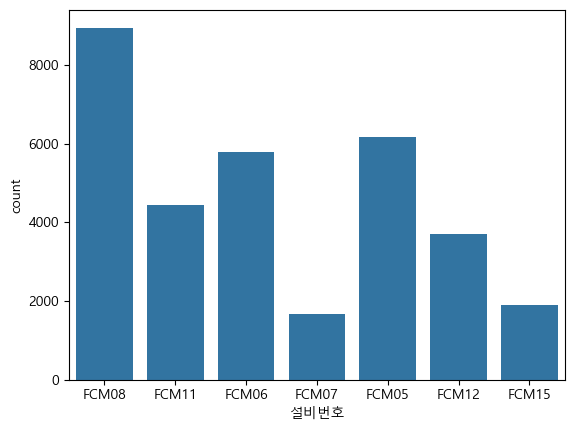

In [287]:
sns.countplot(data=dye, x='설비번호')
plt.show()

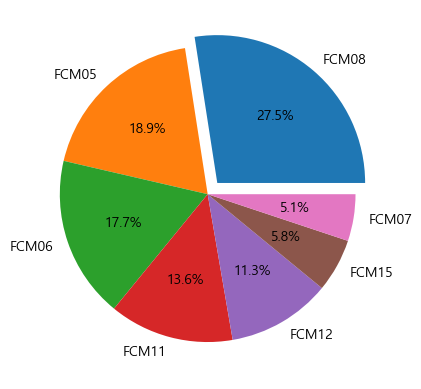

In [289]:
num=dye['설비번호'].value_counts()

plt.pie(x=num.values, 
        labels=num.index,
        autopct='%.1f%%', 
        explode=[0.1, 0, 0, 0, 0, 0, 0])
plt.show()

### 단일변수 - 연속형(숫자) 

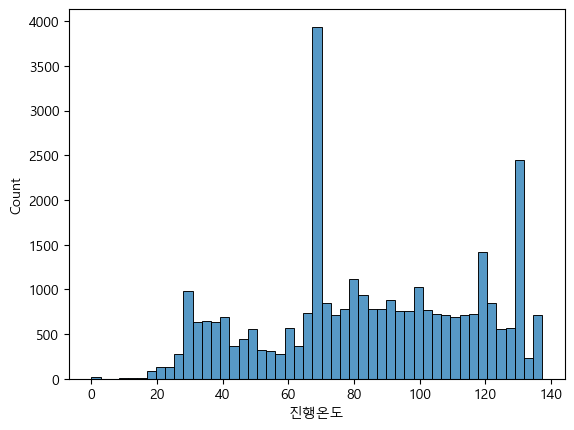

In [294]:
sns.histplot(data=dye, x='진행온도')
plt.show()

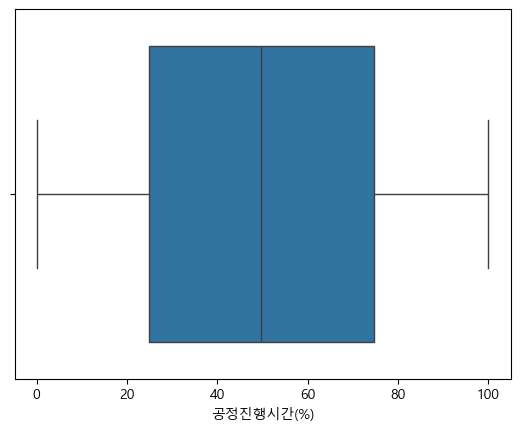

In [301]:
sns.boxplot(data=dye, x='공정진행시간(%)')
plt.show()

### 다 변수 - X(문자) / Y(숫자)

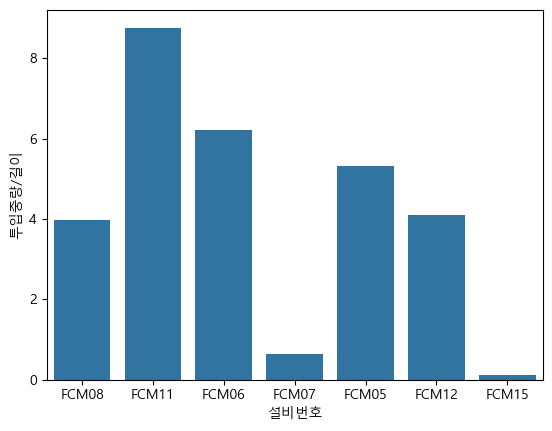

In [310]:
sns.barplot(data=dye, x='설비번호', y='투입중량/길이', errorbar=None)
plt.show()

### 다 변수 - X(숫자) / Y(숫자)

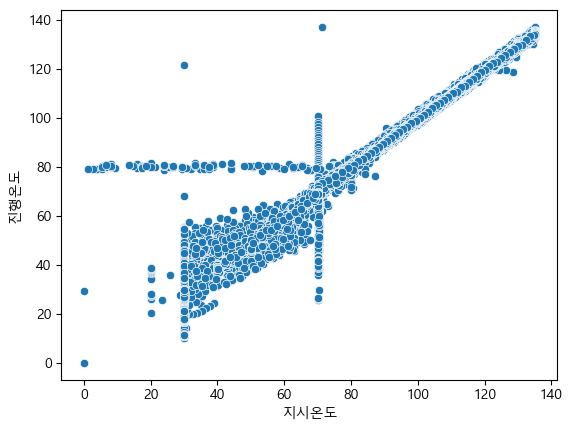

In [317]:
sns.scatterplot(data=dye, x='지시온도', y='진행온도')
plt.show()

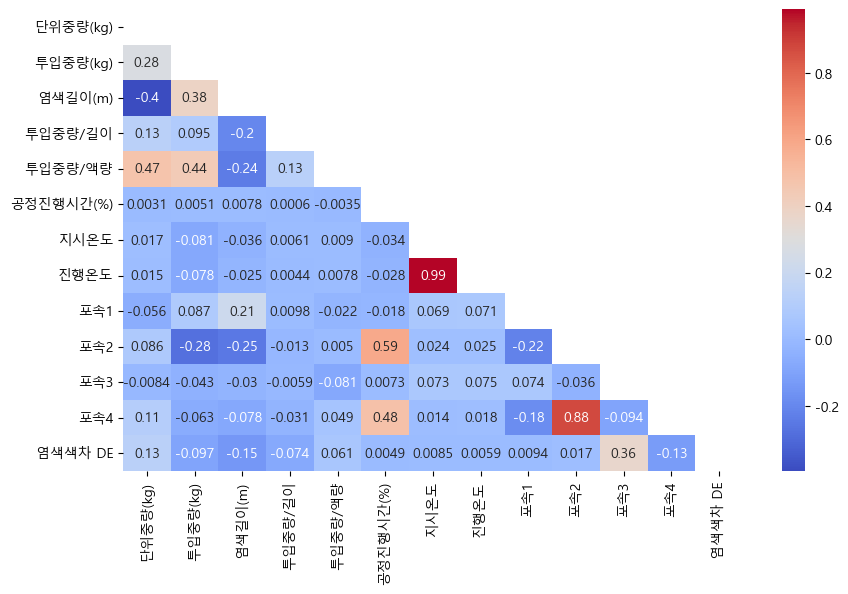

In [322]:
num_corr=dye.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(num_corr,
            annot=True, 
            cmap='coolwarm',   # 쿨윔
            mask=np.triu(np.ones_like(num_corr, dtype=bool)))
plt.show()

In [44]:
# np.ones_like(num_corr, dtype=bool)            # 데이터프레임과 똑같은 크기의 'True'로 가득 찬 행렬
# np.triu(np.ones_like(num_corr, dtype=bool))   # 위쪽 삼각형 부분만 남기고 나머지는 False로 바꿉

# 삼각형 모양의 틀(mask)을 시각화 도구(Seaborn)에 넘겨주면, 
# "True로 되어 있는 부분은 그리지 말고 숨겨라!"라는 뜻으로 작동

### 다 변수 - X(순서형) / Y(숫자)

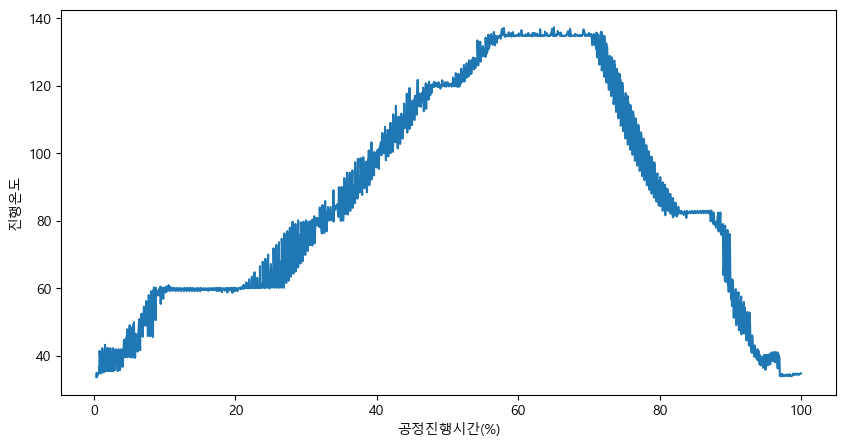

In [328]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=dye[dye['설비번호'] == 'FCM15'], 
             x='공정진행시간(%)', 
             y='진행온도', 
             errorbar=None)
plt.show()

### pairplot 
- 연속형(숫자) 단일, 다변수 같이 한번에 시각화

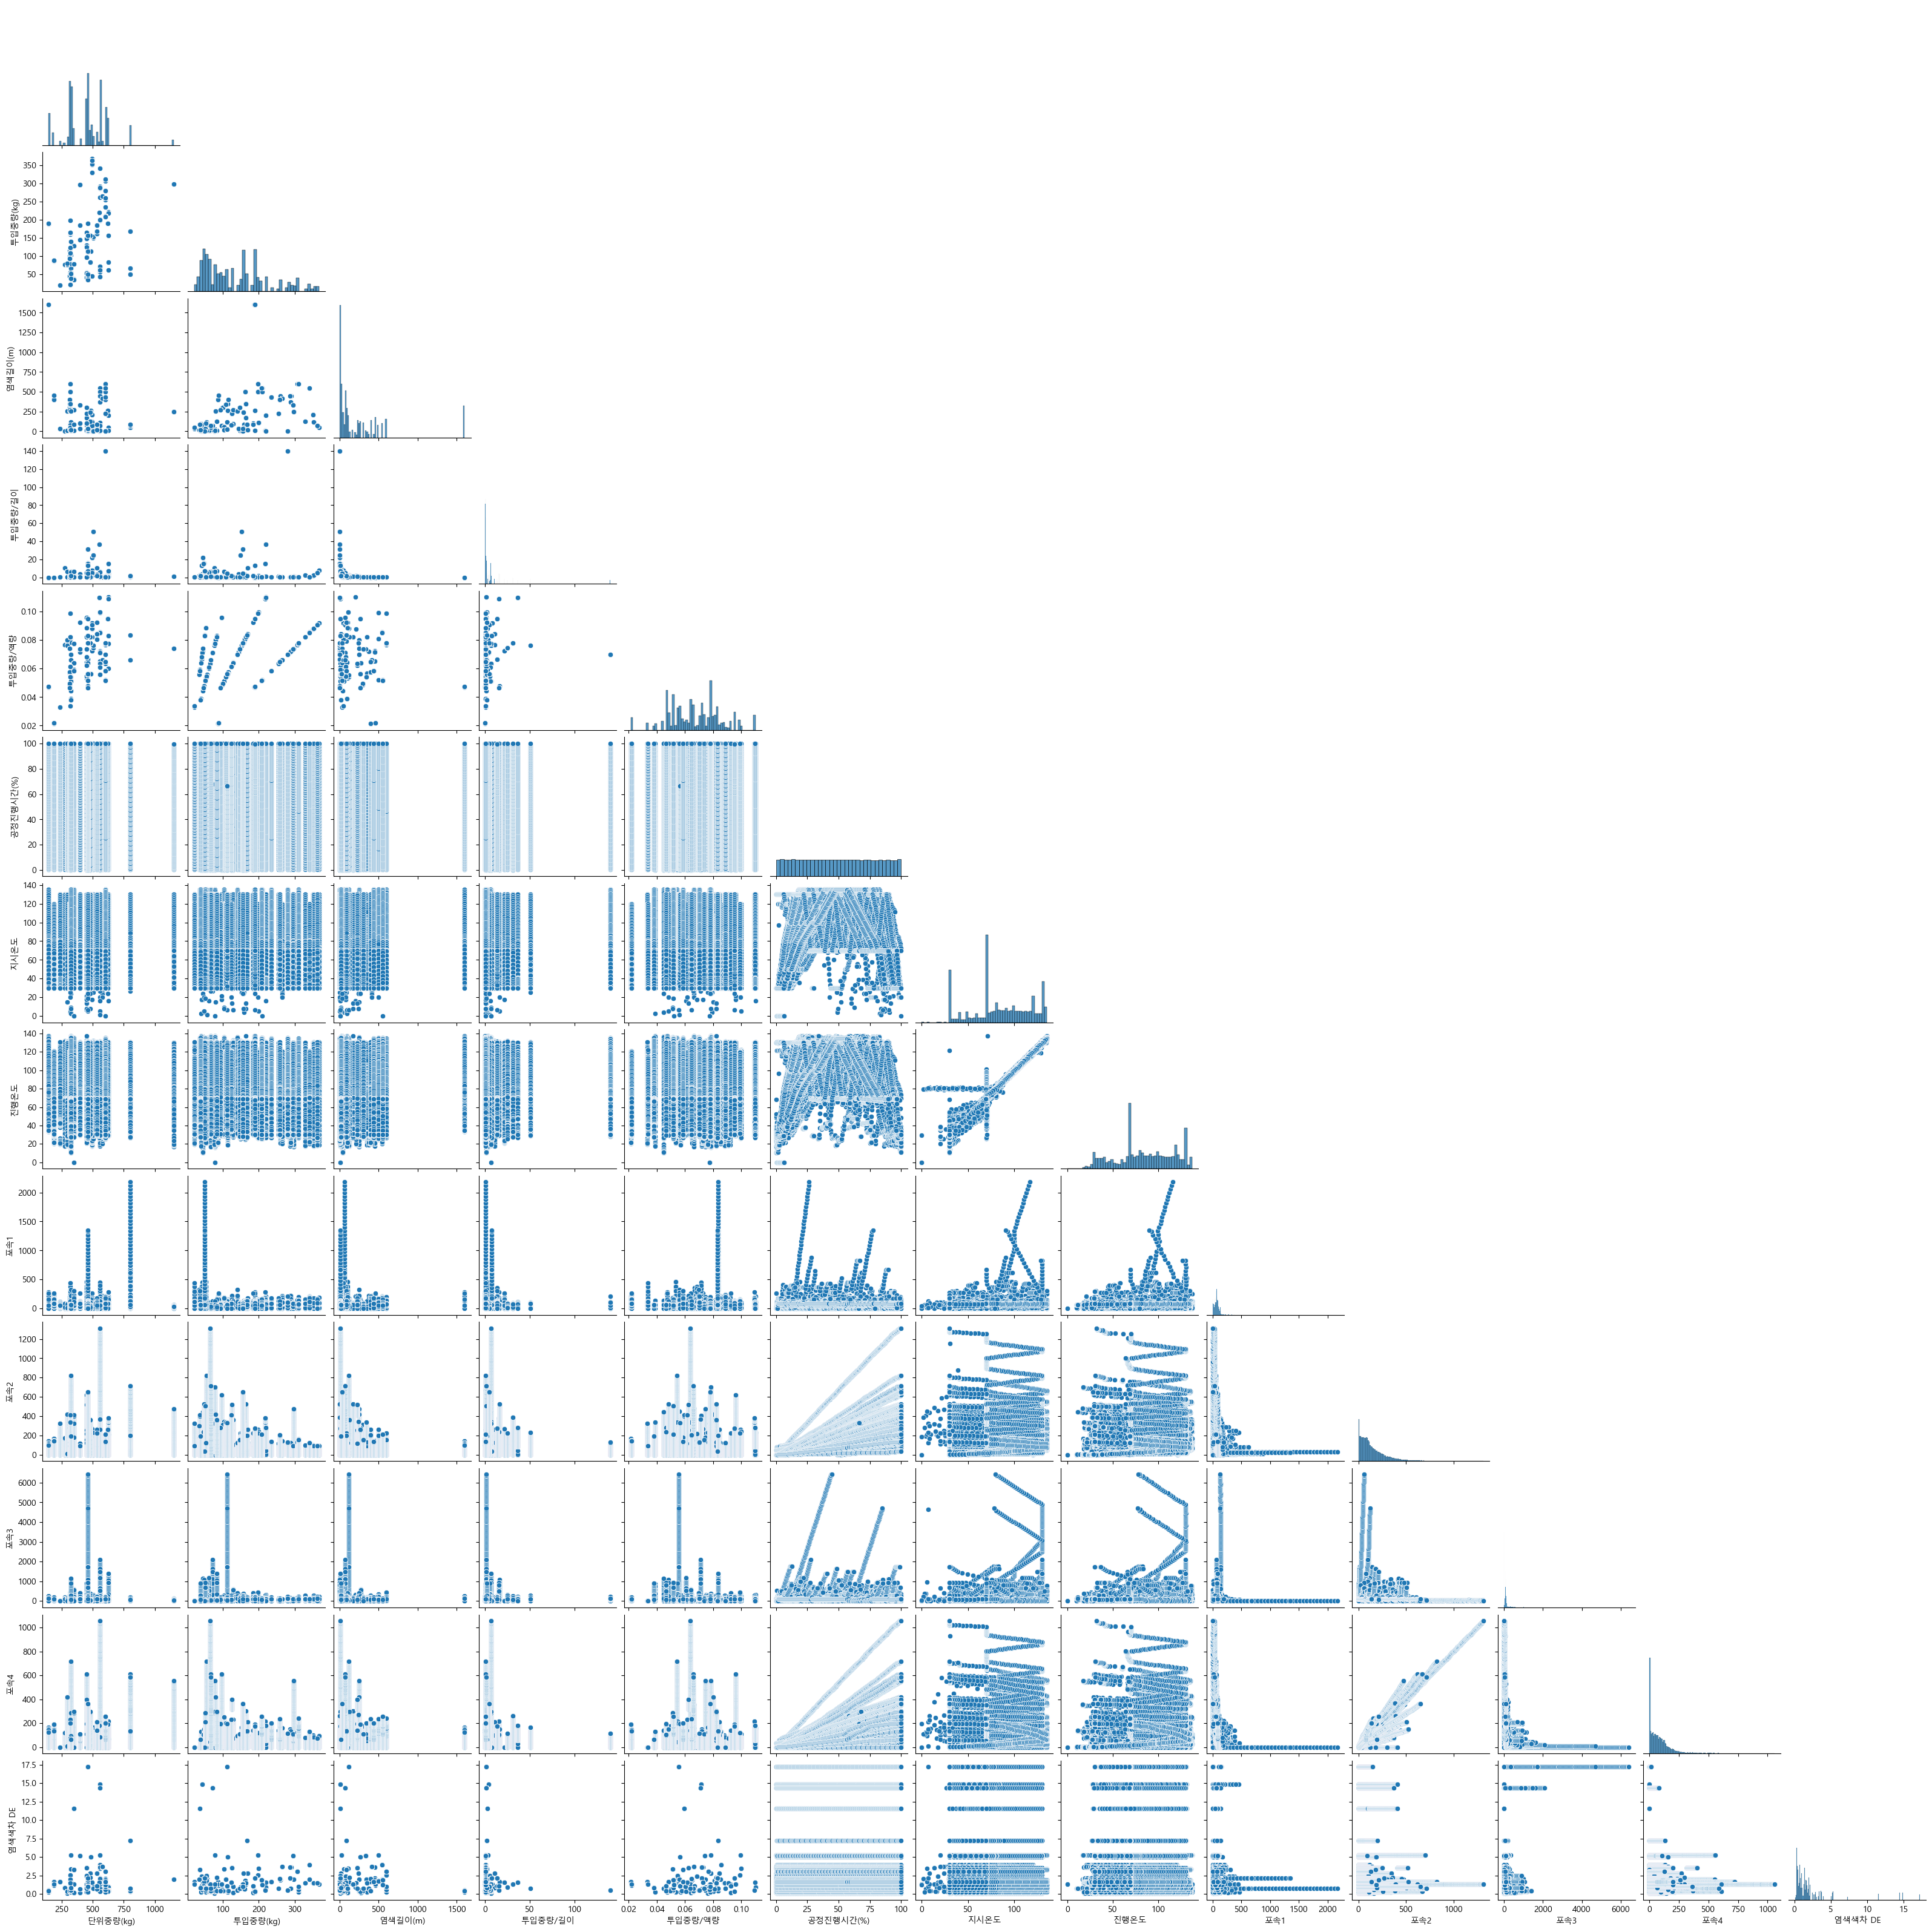

In [338]:
sns.pairplot(data=dye, corner=True)
plt.show()

# 머신러닝 - 종속변수, 독립변수

In [2]:
# 독립변수	 
X=['단위중량(kg)', '투입중량(kg)', '염색길이(m)', '투입중량/길이',	'투입중량/액량', 
   '공정진행시간(%)', '진행온도',	'포속1', '포속3', '포속4'] 

# 종속변수	
Y=['염색색차 DE'] 

In [ ]:
# End of -------------------------------------------------------